<a href="https://colab.research.google.com/github/aman2008-CODER/Open_Sourcery-2.0/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (5572, 2)
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


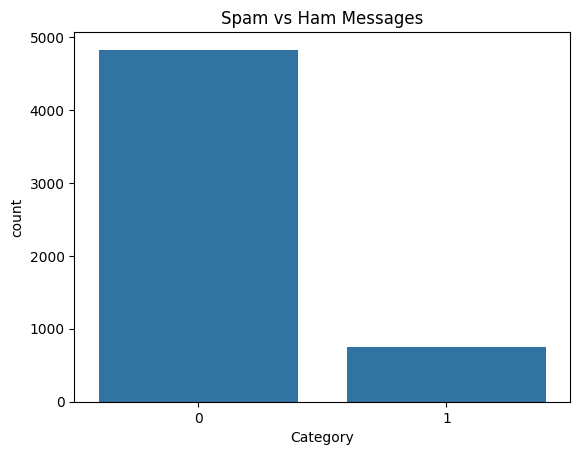

Model Accuracy: 0.9524663677130045


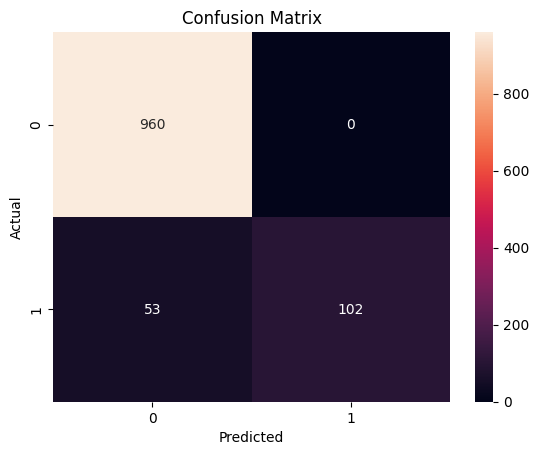

Ham Message


In [4]:
# Spam Detection Machine Learning Project

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Dataset
data = pd.read_csv("/content/sample_data/mail_data.csv")

print("Dataset Shape:", data.shape)
print(data.head())

# 2. Data Cleaning
data = data.fillna('')

# Convert labels
data['Category'] = data['Category'].map({'ham':0, 'spam':1})

# 3. Data Visualization
sns.countplot(x='Category', data=data)
plt.title("Spam vs Ham Messages")
plt.show()

# 4. Separate features and labels
X = data['Message']
Y = data['Category']

# 5. Convert text into numbers (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

# 6. Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

# 7. Train Model
model = LogisticRegression()
model.fit(X_train, Y_train)

# 8. Model Prediction
predictions = model.predict(X_test)

# 9. Accuracy
accuracy = accuracy_score(Y_test, predictions)
print("Model Accuracy:", accuracy)

# 10. Confusion Matrix
cm = confusion_matrix(Y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. Test with New Message
sample = ["Congratulations! You won a free ticket"]
sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")